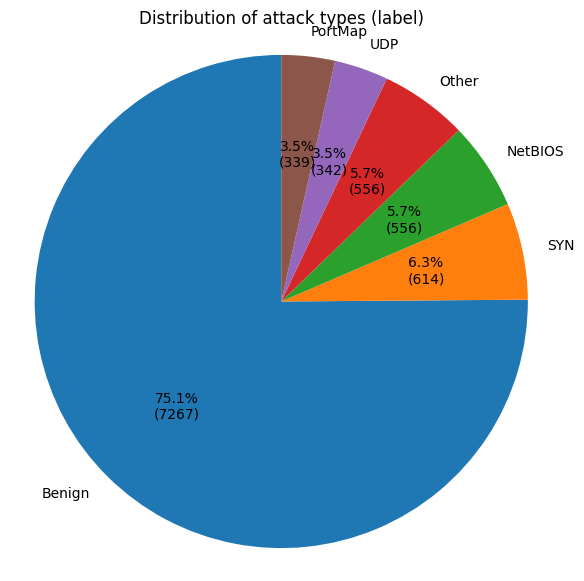

Saved to attack_distribution.png


In [ ]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

try:
    df = pd.read_csv("outputstest.csv")
except FileNotFoundError:
    raise FileNotFoundError("outputstest.csv not found in the working directory.")
except Exception as e:
    raise RuntimeError(f"Error reading outputstest.csv: {e}")
    
candidates = ["attack", "attack_type", "type", "label", "class", "category", "Category"]
attack_col = next((c for c in candidates if c in df.columns), None)

if attack_col is None:
    raise ValueError(f"No obvious attack-type column found. Available columns: {list(df.columns)}")

# Prepare counts
counts = df[attack_col].fillna("Unknown").astype(str).value_counts()

total = counts.sum()
threshold = total * 0.03
small = counts[counts < threshold]
if len(small) > 0:
    counts = counts[counts >= threshold].copy()
    counts["Other"] = small.sum()
counts = counts.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    counts,
    labels=counts.index,
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct * total / 100))})",
    startangle=90,
    textprops={"fontsize": 10}
)
ax.axis("equal")
ax.set_title(f"Distribution of attack types ({attack_col})", fontsize=12)
plt.savefig("attack_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("Saved to attack_distribution.png")

In [2]:
!pip install pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 15.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.0/349.0 KB 28.8 MB/s eta 0:00:00
